In [217]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

,player_api_id,player_name,count_plays,height,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,overall_rating,gk_rating
0,36835.0,Bram Verbist,95.0,182.88,63.14,63.00,68.86,62.57,67.43,64.86,65.00
1,131403.0,Jo Coppens,34.0,190.50,62.75,58.25,62.50,55.00,62.25,59.25,60.15
2,67949.0,Olivier Werner,76.0,190.50,68.36,60.09,61.91,61.55,70.82,64.91,64.55
3,111025.0,Srdjan Blazic,12.0,198.12,71.00,61.00,51.00,64.50,64.50,64.00,62.40
4,20747.0,Eiji Kawashima,110.0,185.42,73.08,66.46,68.54,68.38,78.54,71.23,71.00


Distribution de la taille par rapport au rating


<Axes: xlabel='gk_positioning', ylabel='overall_rating'>

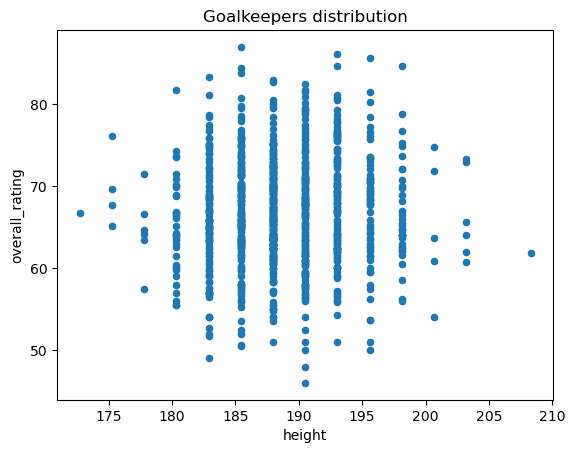

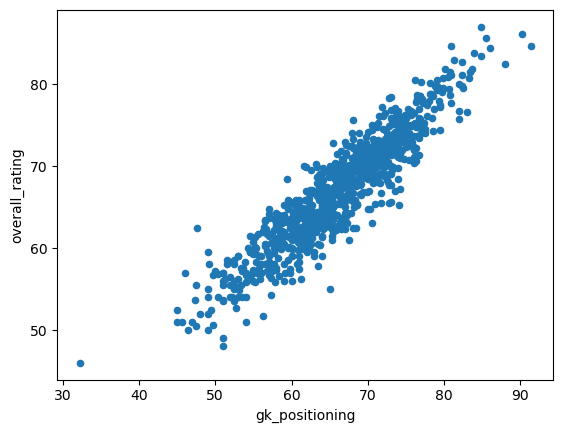

In [218]:
df=pd.read_csv('Data/Projet/Foot/gk_final.csv')
display(df.head())
print('Distribution de la taille par rapport au rating')
df.plot('height','overall_rating',kind='scatter',title='Goalkeepers distribution')
df.plot('gk_positioning','overall_rating',kind='scatter')

,player_api_id,player_name,count_plays,height,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,overall_rating,gk_rating
count,956.00,956,956.00,956.00,956.00,956.00,956.00,956.00,956.00,956.00,956.00
unique,NaN,944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ricardo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,117750.49,NaN,51.75,188.68,68.34,65.14,63.31,65.88,69.80,66.80,66.49
std,130223.97,NaN,60.06,4.73,6.73,7.15,7.25,7.55,7.02,6.56,6.40
min,2796.00,NaN,1.00,172.72,43.00,41.00,39.00,32.25,42.50,46.00,47.40
25%,32656.00,NaN,7.00,185.42,64.00,60.44,58.20,61.08,65.24,62.50,62.28
50%,42919.00,NaN,30.00,187.96,68.21,65.29,63.50,65.88,69.78,66.56,66.44
75%,172240.00,NaN,74.25,191.14,72.80,69.90,68.32,71.00,74.67,71.02,70.70


player_api_id     False
player_name       False
count_plays       False
height            False
gk_diving         False
gk_handling       False
gk_kicking        False
gk_positioning    False
gk_reflexes       False
overall_rating    False
gk_rating         False
dtype: bool

,height,gk_diving,gk_positioning,gk_reflexes
0,182.88,63.14,62.57,67.43
1,190.50,62.75,55.00,62.25
2,190.50,68.36,61.55,70.82
3,198.12,71.00,64.50,64.50
4,185.42,73.08,68.38,78.54
...,...,...,...,...
951,185.42,71.80,67.70,75.20
952,187.96,62.29,58.57,62.14
953,193.04,64.00,57.00,62.00
954,185.42,61.33,55.00,54.33


0      64.86
1      59.25
2      64.91
3      64.00
4      71.23
       ...  
951    69.80
952    59.86
953    59.00
954    57.33
955    65.25
Name: overall_rating, Length: 956, dtype: float64

Text(0.5, 1.0, 'Correlation matrix')

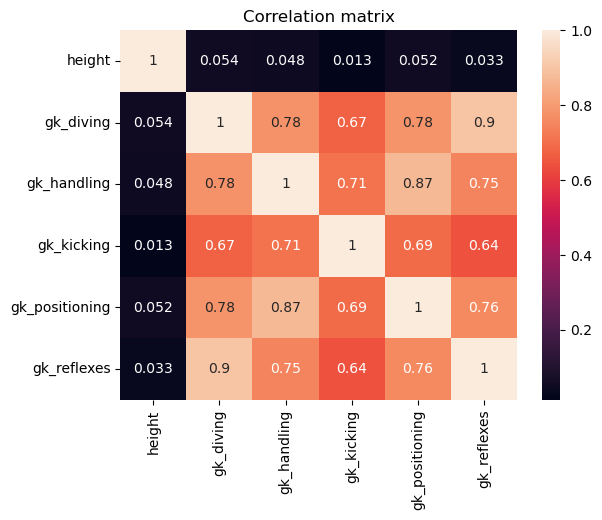

In [219]:
#Premier aperçu
display(df.describe(include='all').round(2))
display(df.isnull().any())
features_list=df.loc[:,['height','gk_diving','gk_positioning','gk_reflexes']]
X=features_list
y=df.loc[:,'overall_rating'] #target
display(X)
display(y)

#Vérif des corrélations
df_corr = df[['height','gk_diving','gk_handling','gk_kicking','gk_positioning','gk_reflexes']].corr()

sns.heatmap (df_corr, annot= True).set_title('Correlation matrix')

In [220]:
#Train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.20, random_state=0)

numeric_features=['height','gk_diving','gk_positioning','gk_reflexes']
numeric_transformer= StandardScaler()

feature_encoder=ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
    ]
)
X_train=feature_encoder.fit_transform(X_train)

display(X_train[0:5,:])

array([[-1.23041374, -0.19840893, -1.03579715,  0.35145984],
       [ 1.44622663,  2.07010309,  1.46386311,  2.05402055],
       [-1.76574181,  0.71667074, -0.55296804,  1.42616594],
       [-1.76574181,  1.38526927, -0.52665583,  1.10658228],
       [ 0.91089855, -0.4714569 ,  0.08773436, -0.28205112]])

In [221]:
print('Train model...')
regressor=LinearRegression()
regressor.fit(X_train,y_train)
print('Done...')

Train model...
Done...


In [222]:
print('Predictions on training set...')
y_train_pred=regressor.predict(X_train)
print('Done...')
print(y_train_pred[:5].round(2))

Predictions on training set...
Done...
[63.98 79.43 69.36 70.23 65.58]


In [223]:
# Testing pipeline
print('--- Testing pipeline ---')
print('Standardizing numerical features...')
print(X_test)

X_test=feature_encoder.transform(X_test)
print(X_test[:5])

--- Testing pipeline ---
Standardizing numerical features...
     height  gk_diving  gk_positioning  gk_reflexes
877  182.88      65.67           61.50        67.33
901  187.96      67.67           70.67        73.00
14   185.42      73.91           71.27        76.27
703  195.58      72.25           74.62        75.38
55   187.96      75.57           68.71        81.00
..      ...        ...             ...          ...
18   185.42      63.57           68.00        69.14
828  187.96      71.50           61.25        72.00
491  187.96      71.47           69.27        73.40
952  187.96      62.29           58.57        62.14
412  187.96      61.50           52.00        58.00

[192 rows x 4 columns]
[[-1.23041374 -0.39470828 -0.57533342 -0.35558364]
 [-0.15975759 -0.09952129  0.63108156  0.44620367]
 [-0.69508566  0.82146212  0.7100182   0.90861011]
 [ 1.44622663  0.57645692  1.15074777  0.78275637]
 [-0.15975759  1.06646732  0.37322187  1.57747324]]


In [224]:
# Predictions on test set
print('Predictions on test set...')
y_test_pred = regressor.predict(X_test)
print('...Done.')
print(y_test_pred[:5].round(2))
print()

Predictions on test set...
...Done.
[63.58 69.31 72.35 72.95 73.15]



In [225]:
# Performance assessment
print('--- Assessing the performances of the model ---')

# Print R^2 scores
print('R2 score on training set : ', regressor.score(X_train, y_train).round(3))
print('R2 score on test set : ', regressor.score(X_test, y_test).round(3))

--- Assessing the performances of the model ---
R2 score on training set :  0.976
R2 score on test set :  0.978


In [226]:
numerical_column_names = X.loc[:,numeric_features].columns # using the .columns attribute gives us the name of the column 
print('numerical columns are: ', numerical_column_names)

numerical columns are:  Index(['height', 'gk_diving', 'gk_positioning', 'gk_reflexes'], dtype='object')


In [227]:
# Feature importance 
feature_importance = pd.DataFrame({
    "feature_names": numerical_column_names,
    "coefficients":regressor.coef_
})

feature_importance

,feature_names,coefficients
0,height,0.026859
1,gk_diving,2.101134
2,gk_positioning,2.948589
3,gk_reflexes,1.899406


c:\Users\safid\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


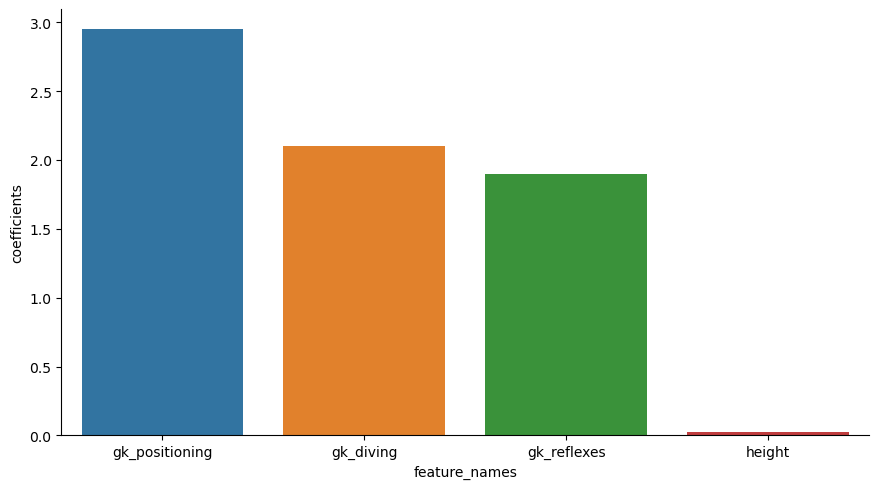

In [228]:
# Set coefficient to absolute values to rank features
feature_importance["coefficients"] = feature_importance["coefficients"].abs()

# Visualize ranked features using seaborn
sns.catplot(x="feature_names", 
            y="coefficients", 
            data=feature_importance.sort_values(by="coefficients", ascending=False), 
            kind="bar",
            aspect=16/9) # Resize graph